# Importing Libraries and Setup

In [1]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd

In [2]:

# os.environ["PROJECT_DIR"] = "/rs1/researchers/a/amallav/"
# print(os.environ["PROJECT_DIR"])
# os.environ["IMAGE_DATASET_DIR"] = "/rs1/researchers/a/amallav/image_dataset"
# print(os.environ["IMAGE_DATASET_DIR"])
# os.environ["OUTPUTS_GD_DIR"] = "/rs1/researchers/a/amallav/results/outputs_gd"
# print(os.environ["OUTPUTS_GD_DIR"])

In [ ]:
PROJECT_DIR = Path(os.environ.get("PROJECT_DIR", "/rs1/researchers/a/amallav/")).resolve()
IMAGE_DATASET_DIR = Path(os.getenv("IMAGE_DATASET_DIR", "/rs1/researchers/a/amallav/image_dataset")).resolve()
# IMAGE_DATASET_DIR = Path(os.getenv("IMAGE_DATASET_DIR", "/rs1/researchers/a/amallav/image_dataset")).expanduser().resolve()
OUTPUTS_DIR=Path(os.environ.get("OUTPUTS_DIR", "/rs1/researchers/a/amallav/results")).resolve()

OUTPUTS_GD_DIR = Path(os.environ.get("OUTPUTS_GD_DIR", OUTPUTS_DIR / "outputs_gd_round2")).resolve()

OUTPUTS_CP_DIR = Path(os.environ.get("OUTPUTS_CP_DIR", OUTPUTS_DIR / "outputs_crop_round2")).resolve() #looks for environment variable OUTPUTS_DIR, if not found uses PROJECT_DIR / "outputs_crop"
OUTPUTS_CP_DIR.mkdir(parents=True, exist_ok=True) #create the output folder if it doesn’t already exist



csv_file = "bounding_boxes.csv"            # CSV containing bounding boxes
print("PROJECT_DIR:", PROJECT_DIR)
print("IMAGE_DATASET_DIR:", IMAGE_DATASET_DIR, "| exists:", IMAGE_DATASET_DIR.exists())
print("OUTPUTS_DIR:", OUTPUTS_DIR, "| exists:", OUTPUTS_DIR.exists())
print("OUTPUTS_GD_DIR:", OUTPUTS_GD_DIR, "| exists:", OUTPUTS_GD_DIR.exists())
print("OUTPUTS_CP_DIR:", OUTPUTS_CP_DIR, "| exists:", OUTPUTS_CP_DIR.exists())
print("CSV path:", csv_file)


PROJECT_DIR: /rs1/researchers/a/amallav
IMAGE_DATASET_DIR: /rs1/researchers/a/amallav/image_dataset | exists: True
OUTPUTS_DIR: /rs1/researchers/a/amallav/results | exists: True
OUTPUTS_GD_DIR: /rs1/researchers/a/amallav/results/outputs_gd_round2 | exists: True
OUTPUTS_CP_DIR: /rs1/researchers/a/amallav/results/outputs_crop | exists: True
CSV path: bounding_boxes.csv


# Load Image Files and CSV

In [4]:

# # IMAGE FILE NAMES OF INTEREST (without extension)

# target_images = {
#     "obs_10317797_photo_14298032",
#     "obs_33435868_photo_52515163",
#     "obs_64497720_photo_103704678",
#     "obs_102691691_photo_171703626",
#     "obs_130480768_photo_70327211",
#     "obs_188731534_photo_330410184",
#     "obs_194599339_photo_342107100",
#     "obs_194795499_photo_341224314",
#     "obs_195713651_photo_344383957",
#     "obs_220102252_photo_389649357",
#     "obs_220822650_photo_391000325",
#     "obs_250956763_photo_448935283",
#     "obs_256022699_photo_458927175",
#     "obs_258568965_photo_463949088",
#     "obs_263836670_photo_474047112",
#     "obs_264953671_photo_475827468",
#     "obs_291009479_photo_523542929",
#     "obs_302755190_photo_545634287",
#     "obs_318344322_photo_575337712",
#     "obs_318533969_photo_575706140",
#     "obs_319669394_photo_577875426",
#     "obs_321389820_photo_581234419",
#     "obs_323944435_photo_586236533",
#     "obs_325267824_photo_588882003",
#     "obs_325625055_photo_589595206",
#     "obs_326876805_photo_592092171",
#     "obs_327076113_photo_592488640",
#     "obs_331752340_photo_601901044",
#     "obs_331831594_photo_602051260",
#     "obs_332241462_photo_602909620",
#     "obs_333144263_photo_501540234",
#     "obs_333664707_photo_605748155",
#     "obs_334025380_photo_606497684",
#     "obs_334758419_photo_607987821",
#     "obs_336269939_photo_611037472",
#     "obs_337063055_photo_612648507",
#     "obs_337600645_photo_614526508",
#     "obs_337606242_photo_613762919",
#     "obs_337610708_photo_613769550",
#     "obs_337610714_photo_613769638",
#     "obs_338007030_photo_614585734",
#     "obs_338486970_photo_615576074",
#     "obs_339993526_photo_618618071",
#     "obs_340263466_photo_619175705",
#     "obs_340271186_photo_619190124",
#     "obs_340304697_photo_619256274",
#     "obs_340326193_photo_619295159",
#     "obs_340326194_photo_619295158",
#     "obs_340337296_photo_536341964",
#     "obs_340337865_photo_533753896",
#     "obs_340364592_photo_619375042",
#     "obs_340368188_photo_619383348",
#     "obs_340433312_photo_619519266",
#     "obs_340514309_photo_619678757",
#     "obs_340514310_photo_619679014",
#     "obs_340542613_photo_619737737",
#     "obs_340825934_photo_620308797",
#     "obs_340848497_photo_620354560",
#     "obs_340848514_photo_620354575",
#     "obs_340848746_photo_620355031",
#     "obs_341060278_photo_547585371",
#     "obs_341067936_photo_620805844",
#     "obs_341194952_photo_621071156",
# }
file_path = os.path.join(OUTPUTS_GD_DIR, csv_file)
file_path




'/rs1/researchers/a/amallav/results/outputs_gd_round2/bounding_boxes.csv'

In [5]:
df = pd.read_csv(file_path)
df

,observation_id,photo_id,image_path,label,score,x1,y1,x2,y2
0,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,large carnivorous mammal,0.522535,0.918754,1.161777,347.949524,393.260620
1,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,long body short legs,0.296364,2.406338,0.923658,350.270081,229.638428
2,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,large carnivorous mammal,0.293041,1.947423,-1.223329,346.906586,246.456009
3,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,distinctive scent glands,0.228491,82.458549,66.588287,176.872986,163.675720
4,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,long body,0.209122,0.515449,1.017983,347.882385,392.428162
...,...,...,...,...,...,...,...,...,...
67096,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.303589,16.435129,24.658554,858.379639,1302.985107
67097,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.264472,29.750486,43.838535,633.683716,1263.799316
67098,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.253528,39.428810,14.287791,693.087463,1350.292480
67099,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.253304,9.334228,9.471861,868.872925,1348.242798


In [6]:
required_cols = {"image_path", "x1", "y1", "x2", "y2"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

In [7]:
# Normalize image names in CSV by removing extension
df['image_id'] = df['image_path'].apply(lambda p: Path(p).stem)
df

,observation_id,photo_id,image_path,label,score,x1,y1,x2,y2,image_id
0,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,large carnivorous mammal,0.522535,0.918754,1.161777,347.949524,393.260620,obs_100052837_photo_166933111_box1
1,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,long body short legs,0.296364,2.406338,0.923658,350.270081,229.638428,obs_100052837_photo_166933111_box1
2,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,large carnivorous mammal,0.293041,1.947423,-1.223329,346.906586,246.456009,obs_100052837_photo_166933111_box1
3,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,distinctive scent glands,0.228491,82.458549,66.588287,176.872986,163.675720,obs_100052837_photo_166933111_box1
4,100052837,166933111,/rs1/researchers/a/amallav/results/outputs_cro...,long body,0.209122,0.515449,1.017983,347.882385,392.428162,obs_100052837_photo_166933111_box1
...,...,...,...,...,...,...,...,...,...,...
67096,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.303589,16.435129,24.658554,858.379639,1302.985107,obs_99990956_photo_166796345_box2
67097,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.264472,29.750486,43.838535,633.683716,1263.799316,obs_99990956_photo_166796345_box2
67098,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.253528,39.428810,14.287791,693.087463,1350.292480,obs_99990956_photo_166796345_box2
67099,99990956,166796345,/rs1/researchers/a/amallav/results/outputs_cro...,purple crested bird,0.253304,9.334228,9.471861,868.872925,1348.242798,obs_99990956_photo_166796345_box2


In [8]:

# # Keep only requested images
# df = df[df["image_id"].isin(target_images)].copy()

# print(f"Total bbox rows selected: {len(df)}")
# print(f"Unique target images found in CSV: {df['image_id'].nunique()}")


In [9]:

# # =========================
# # HELPER: find actual image file in folder
# # =========================
# valid_exts = [".jpg", ".jpeg", ".png", ".webp"]

# def find_image_path(image_stem, images_folder):
#     for ext in valid_exts:
#         candidate = os.path.join(images_folder, image_stem + ext)
#         if os.path.exists(candidate):
#             return candidate

#     # fallback: search all files by stem
#     for fname in os.listdir(images_folder):
#         if Path(fname).stem == image_stem:
#             return os.path.join(images_folder, fname)

#     return None

In [ ]:

# =========================
# CROP AND SAVE
# =========================
saved_records = []

for image_path, group in df.groupby("image_path"):
    image_path = image_path

    if image_path is None:
        print(f"[WARNING] Image not found for: {image_path}")
        continue

    try:
        img = Image.open(image_path).convert("RGB")
        img_w, img_h = img.size
    except Exception as e:
        print(f"[ERROR] Could not open {image_path}: {e}")
        continue

    for box_num, row in enumerate(group.itertuples(index=False), start=1):
        x_min = int(row.x1)
        y_min = int(row.y1)
        x_max = int(row.x2)
        y_max = int(row.y2)
        # rank= int(row.rank)

        # clip coordinates within image bounds
        x_min = max(0, min(x_min, img_w - 1))
        y_min = max(0, min(y_min, img_h - 1))
        x_max = max(0, min(x_max, img_w))
        y_max = max(0, min(y_max, img_h))

        # skip invalid box
        if x_max <= x_min or y_max <= y_min:
            print(f"[SKIP] Invalid box for {image_path}, box {box_num}")
            continue

        cropped = img.crop((x_min, y_min, x_max, y_max)) #img.crop((left, upper, right, lower))
        image_stem=row.image_id
        save_name = f"{image_stem}_box{box_num}.jpg"
        save_path = os.path.join(OUTPUTS_CP_DIR, save_name)

        cropped.save(save_path, quality=95)

        saved_records.append({
            "original_image": os.path.basename(image_path),
            "image_path": image_path,
            "box_num": box_num,
            # "rank":rank,
            "image_id":image_stem,
            "crop_file": save_name,
            "crop_file_path":save_path,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max,
        })

        print(f"[SAVED] {save_path}")

[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box1_box1.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box1_box2.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box1_box3.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box1_box4.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box1_box5.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box2_box1.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box2_box2.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box3_box1.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box4_box1.jpg
[SAVED] /rs1/researchers/a/amallav/results/outputs_crop/obs_100052837_photo_166933111_box4_box2.jpg


In [11]:
# Save crop metadata too
if saved_records:
    crops_df = pd.DataFrame(saved_records)
    crops_df.to_csv(os.path.join(OUTPUTS_CP_DIR, "cropped_metadata.csv"), index=False)
    print(f"\nSaved metadata CSV: {os.path.join(OUTPUTS_CP_DIR, 'cropped_metadata.csv')}")

print("\nDone.")


Saved metadata CSV: /rs1/researchers/a/amallav/results/outputs_crop/cropped_metadata.csv

Done.


In [ ]:
# df=pd.read_csv("/rs1/researchers/a/amallav/results/outputs_crop/cropped_metadata.csv")
# df

,original_image,image_path,box_num,image_id,crop_file,crop_file_path,x_min,y_min,x_max,y_max
0,obs_10317797_photo_14298032_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,1,obs_10317797_photo_14298032_box1,obs_10317797_photo_14298032_box1_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,0,557,218,688
1,obs_10317797_photo_14298032_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,2,obs_10317797_photo_14298032_box1,obs_10317797_photo_14298032_box1_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,2,1,652,722
2,obs_10317797_photo_14298032_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,1,obs_10317797_photo_14298032_box2,obs_10317797_photo_14298032_box2_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,1,4,231,132
3,obs_10317797_photo_14298032_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,2,obs_10317797_photo_14298032_box2,obs_10317797_photo_14298032_box2_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,33,24,84,66
4,obs_130480768_photo_70327211_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,1,obs_130480768_photo_70327211_box1,obs_130480768_photo_70327211_box1_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,11,12,2005,810
...,...,...,...,...,...,...,...,...,...,...
313,obs_340848514_photo_620354575_box4.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,3,obs_340848514_photo_620354575_box4,obs_340848514_photo_620354575_box4_box3.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,84,215,130,262
314,obs_340848514_photo_620354575_box4.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,4,obs_340848514_photo_620354575_box4,obs_340848514_photo_620354575_box4_box4.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,7,4,216,471
315,obs_340848514_photo_620354575_box4.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,5,obs_340848514_photo_620354575_box4,obs_340848514_photo_620354575_box4_box5.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,82,214,131,365
316,obs_64497720_photo_103704678_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,1,obs_64497720_photo_103704678_box1,obs_64497720_photo_103704678_box1_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,11,9,756,406


In [ ]:

# mask = df[df["original_image"] == "obs_340848514_photo_620354575_box1.jpg"]

# # # img_pil = Image.open(img_path).convert("RGB")
# # img_path = df.loc[mask, "crop_file_path"].iloc[0] 
# # img_path
# len(mask["crop_file_path"])


3

In [ ]:
# # path=mask["crop_file_path"].iloc[0]
# path = "/rs1/researchers/a/amallav/results/outputs_crop/obs_220822650_photo_391000325_box1.jpg"
# path

'/rs1/researchers/a/amallav/results/outputs_crop/obs_220822650_photo_391000325_box1.jpg'

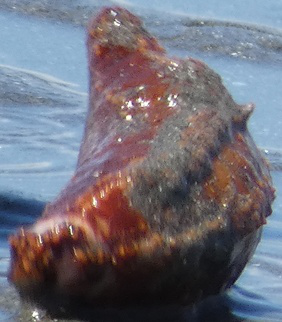

In [ ]:
# img_pil = Image.open(path).convert("RGB")
# display(img_pil)